<div style="text-align: center; font-family: Arial, sans-serif; font-size: 12pt; line-height: 1.5;">

## UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
### Centro de Ciencias Básicas
### Departamento de Ciencias de la Computación
### Academia de Inteligencia Artificial

---

# Sistema de Reconocimiento de Huellas Dactilares
### Implementación mediante Red Neuronal Convolucional (CNN)

---

| Campo | Información |
|:---|:---|
| **Materia** | Machine Learning – Deep Learning |
| **Profesor** | Dr. Francisco Javier Luna Rosas |
| **Carrera** | Ingeniería en Computación Inteligente (ICI) |
| **Semestre** | 10° |
| **Periodo** | Enero – Junio 2026 |
| **Tipo de Examen** | 2° Parcial |
| **Fecha** | Mayo 2026 |
| **Alumno** | Carlos Daniel Torres Macias |

</div>

---
## Introducción

Un sistema de reconocimiento de huellas dactilares es una tecnología biométrica que identifica a una persona a partir de los patrones únicos presentes en sus huellas dactilares. Estos patrones —conocidos como *minucias*— incluyen bifurcaciones, terminaciones de crestas y arcos que son exclusivos de cada individuo, lo que convierte la huella dactilar en uno de los identificadores biométricos más confiables y ampliamente utilizados en sistemas de seguridad modernos.

Las **Redes Neuronales Convolucionales** (*Convolutional Neural Networks*, CNN) representan una de las arquitecturas de mayor impacto en el campo del aprendizaje profundo aplicado al reconocimiento de imágenes. A diferencia de las redes neuronales densas tradicionales, las CNN aprenden automáticamente jerarquías de características espaciales —bordes, texturas y patrones— mediante capas convolucionales con pesos compartidos, lo cual reduce la cantidad de parámetros y mejora la capacidad de generalización ante datos no vistos durante el entrenamiento.

En este trabajo se desarrolla un **Sistema de Reconocimiento de Huellas Dactilares** estructurado en cuatro etapas:

1. **Recolección de Datos:** Captura y organización del dataset de huellas dactilares.
2. **Transformación de Datos:** Preprocesamiento, normalización y aumento de datos.
3. **Modelo CNN:** Diseño, compilación, entrenamiento y evaluación de la red neuronal.
4. **Reconocimiento:** Predicción e identificación de huellas con el modelo entrenado.

---
## 1. Recolección de Datos

Para la construcción del dataset se utilizó la **cámara de un dispositivo móvil** como herramienta de captura. Las imágenes fueron tomadas bajo condiciones controladas de iluminación, variando ligeramente el ángulo, la presión y la posición del dedo entre cada captura para introducir diversidad en las muestras y mejorar la capacidad de generalización del modelo.

Las imágenes se almacenan en la carpeta `huellas/`, organizada con una subcarpeta por clase (un dedo distinto). La estructura del proyecto es la siguiente:
Examen_II/
├── Examen_II_CNN_Huellas.ipynb
└── huellas/
├── pulgar/      ← Imágenes del dedo pulgar
├── indice/      ← Imágenes del dedo índice
└── medio/       ← Imágenes del dedo medio


A continuación se cargan todas las imágenes del dataset y se presentan ejemplos representativos de cada clase.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Importación de Librerías
# ─────────────────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"OpenCV     : {cv2.__version__}")

I0000 00:00:1777905888.836384    6731 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777905888.845059    6731 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777905890.014584    6731 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777905894.860447    6731 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow : 2.21.0
NumPy      : 2.4.3
OpenCV     : 4.13.0


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Parámetros Globales del Dataset
# ─────────────────────────────────────────────────────────────────────────────
DATASET_DIR = "huellas"
IMG_SIZE    = (128, 128)
IMG_H, IMG_W = IMG_SIZE

# ─────────────────────────────────────────────────────────────────────────────
# Función: Cargar Imágenes desde Subdirectorios
# Cada subdirectorio representa una clase (un dedo).
# ─────────────────────────────────────────────────────────────────────────────
def cargar_dataset(dataset_dir, img_size):
    imagenes, etiquetas = [], []
    extensiones = ('.jpg', '.jpeg', '.png', '.bmp')

    clases = sorted([
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    ])

    print("Clases detectadas:", clases)
    print()

    for idx, clase in enumerate(clases):
        ruta_clase = os.path.join(dataset_dir, clase)
        archivos   = [f for f in os.listdir(ruta_clase)
                      if f.lower().endswith(extensiones)]

        print(f"  Clase [{idx}]  '{clase}': {len(archivos)} imágenes")

        for archivo in archivos:
            ruta_img = os.path.join(ruta_clase, archivo)
            img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                imagenes.append(img)
                etiquetas.append(idx)

    return np.array(imagenes), np.array(etiquetas), clases


X_raw, y_raw, CLASES = cargar_dataset(DATASET_DIR, IMG_SIZE)
N_CLASES = len(CLASES)

print()
print(f"Total de imágenes cargadas : {len(X_raw)}")
print(f"Número de clases           : {N_CLASES}")
print(f"Shape del array de imágenes: {X_raw.shape}")

Clases detectadas: ['indice', 'medio', 'pulgar']

  Clase [0]  'indice': 206 imágenes
  Clase [1]  'medio': 200 imágenes
  Clase [2]  'pulgar': 200 imágenes

Total de imágenes cargadas : 606
Número de clases           : 3
Shape del array de imágenes: (606, 128, 128)


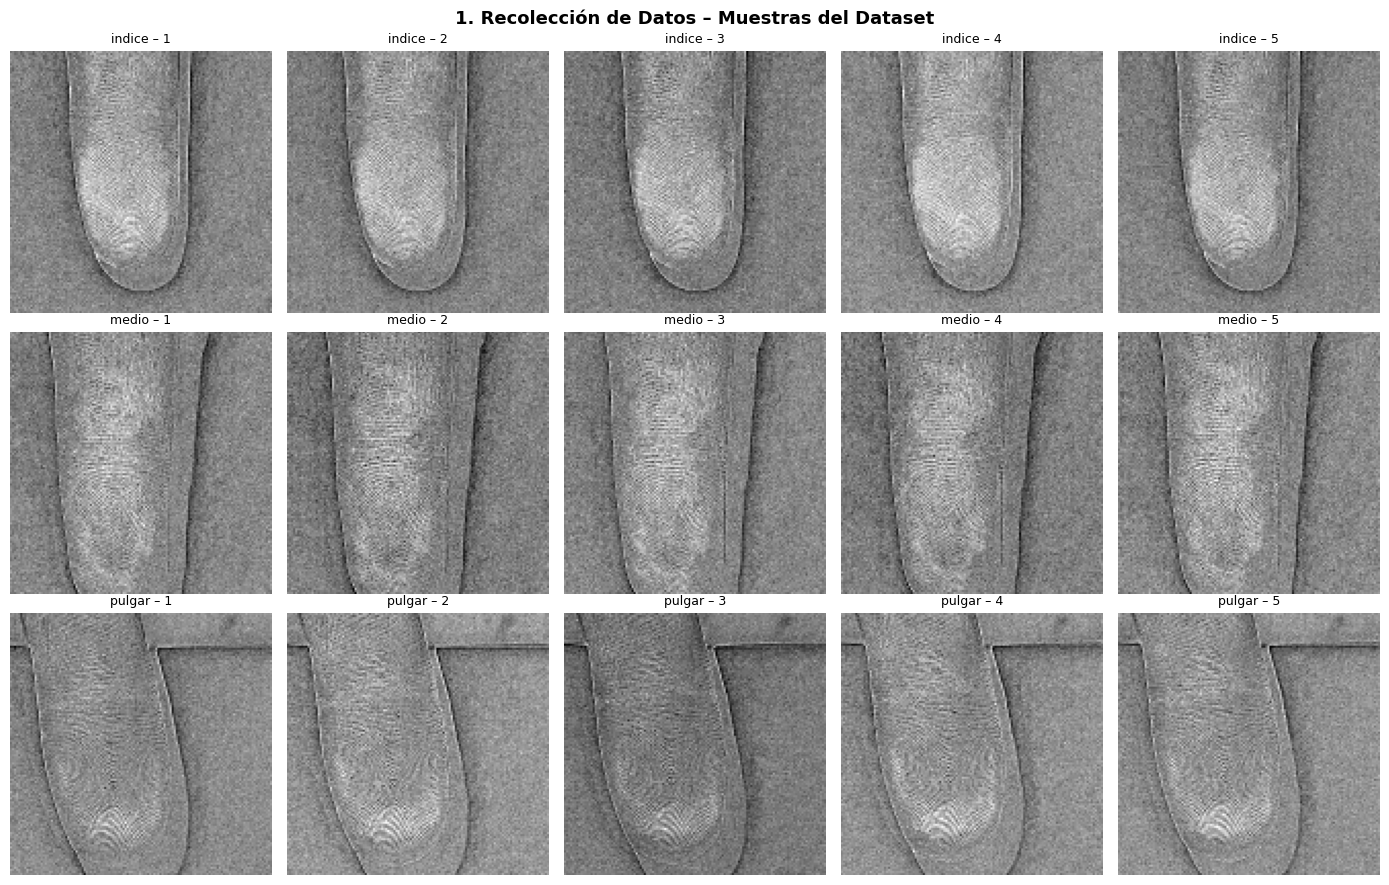

Figura guardada: fig1_recoleccion.png


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización de Muestras por Clase
# ─────────────────────────────────────────────────────────────────────────────
N_COLS = 5
fig, axes = plt.subplots(N_CLASES, N_COLS,
                         figsize=(14, 3 * N_CLASES),
                         squeeze=False)
fig.suptitle("1. Recolección de Datos – Muestras del Dataset",
             fontsize=13, fontweight='bold')

for cls_idx, clase in enumerate(CLASES):
    idx_clase = np.where(y_raw == cls_idx)[0]
    muestras  = idx_clase[:N_COLS]

    for col, sample_idx in enumerate(muestras):
        axes[cls_idx][col].imshow(X_raw[sample_idx], cmap='gray')
        axes[cls_idx][col].set_title(f"{clase} – {col + 1}", fontsize=9)
        axes[cls_idx][col].axis('off')

    for col in range(len(muestras), N_COLS):
        axes[cls_idx][col].axis('off')

plt.tight_layout()
plt.savefig("fig1_recoleccion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig1_recoleccion.png")

---
## 2. Transformación de Datos

La etapa de transformación prepara las imágenes en crudo para que la CNN pueda procesarlas de manera eficiente y estandarizada. Las operaciones aplicadas se describen a continuación:

| Transformación | Descripción |
|:---|:---|
| **Escala de grises** | Un solo canal reduce la complejidad computacional conservando los patrones relevantes de la huella |
| **Redimensionamiento** | Todas las imágenes se estandarizan a **128 × 128 píxeles** |
| **Normalización** | Los valores de píxel se escalan al rango **[0, 1]** dividiendo entre 255 |
| **Codificación *one-hot*** | Las etiquetas numéricas se convierten a vectores binarios (ej. clase 1 → `[0, 1, 0]`) |
| **Aumento de datos** | Se generan variaciones artificiales —rotaciones, desplazamientos, zoom— para ampliar el dataset |

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Normalización y Codificación One-Hot
# ─────────────────────────────────────────────────────────────────────────────

# Agregar dimensión de canal: (N, H, W) → (N, H, W, 1)
X    = X_raw.astype('float32') / 255.0
X    = X[..., np.newaxis]

# Codificación One-Hot de las etiquetas
y_oh = to_categorical(y_raw, num_classes=N_CLASES)

print(f"Shape X (normalizado) : {X.shape}")
print(f"Shape y (one-hot)     : {y_oh.shape}")
print(f"Rango de valores      : [{X.min():.2f}, {X.max():.2f}]")
print()
print("Ejemplo de codificación one-hot por clase:")
for i, clase in enumerate(CLASES):
    ejemplo = y_oh[np.where(y_raw == i)[0][0]]
    print(f"  {clase:>10}  →  {ejemplo}")

Shape X (normalizado) : (606, 128, 128, 1)
Shape y (one-hot)     : (606, 3)
Rango de valores      : [0.00, 0.86]

Ejemplo de codificación one-hot por clase:
      indice  →  [1. 0. 0.]
       medio  →  [0. 1. 0.]
      pulgar  →  [0. 0. 1.]


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# División del Dataset: Entrenamiento / Validación / Prueba
# Proporciones objetivo: 70% | 15% | 15%
# ─────────────────────────────────────────────────────────────────────────────
try:
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y_oh, test_size=0.15, random_state=SEED, stratify=y_raw
    )
    y_temp_labels = np.argmax(y_temp, axis=1)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=0.176,        # 0.176 × 0.85 ≈ 0.15 del total
        random_state=SEED,
        stratify=y_temp_labels
    )
except ValueError:
    # Dataset muy pequeño: división sin estratificación
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y_oh, test_size=0.15, random_state=SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=SEED
    )

total = len(X)
print("División del dataset:")
print(f"  Entrenamiento : {len(X_train):>3} imágenes  ({len(X_train)/total*100:.1f}%)")
print(f"  Validación    : {len(X_val):>3} imágenes  ({len(X_val)/total*100:.1f}%)")
print(f"  Prueba        : {len(X_test):>3} imágenes  ({len(X_test)/total*100:.1f}%)")

División del dataset:
  Entrenamiento : 424 imágenes  (70.0%)
  Validación    :  91 imágenes  (15.0%)
  Prueba        :  91 imágenes  (15.0%)


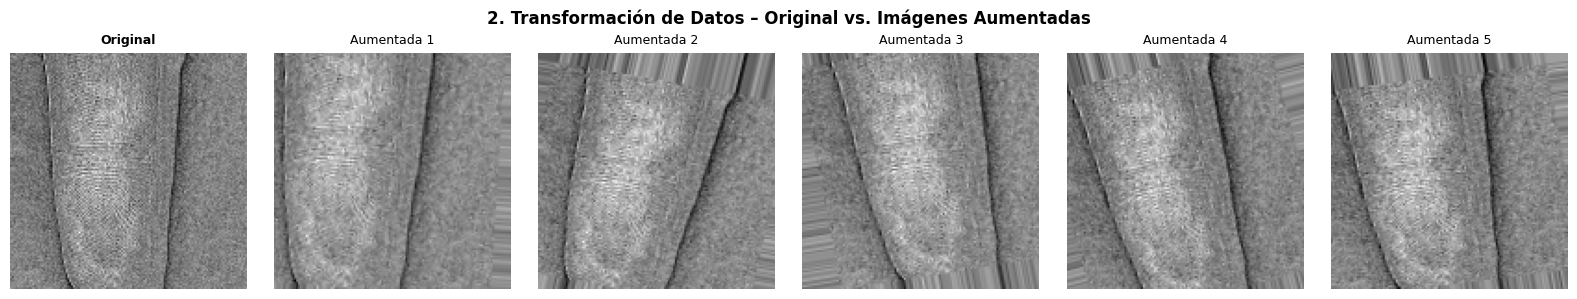

Figura guardada: fig2_transformacion.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Configuración del Aumento de Datos (Data Augmentation)
# ─────────────────────────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range     = 15,     # Rotación aleatoria ±15°
    width_shift_range  = 0.10,   # Desplazamiento horizontal ±10%
    height_shift_range = 0.10,   # Desplazamiento vertical ±10%
    zoom_range         = 0.15,   # Zoom aleatorio ±15%
    shear_range        = 0.10,   # Cizallamiento ±10%
    horizontal_flip    = False,  # Sin volteo horizontal (huellas no son simétricas)
    fill_mode          = 'nearest'
)
datagen.fit(X_train)

# ─────────────────────────────────────────────────────────────────────────────
# Visualización: Imagen Original vs. Imágenes Aumentadas
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
fig.suptitle("2. Transformación de Datos – Original vs. Imágenes Aumentadas",
             fontsize=12, fontweight='bold')

sample = X_train[0:1]
axes[0].imshow(sample[0, :, :, 0], cmap='gray')
axes[0].set_title("Original", fontweight='bold', fontsize=9)
axes[0].axis('off')

gen = datagen.flow(sample, batch_size=1, seed=SEED)
for col in range(1, 6):
    aug = next(gen)[0, :, :, 0]
    axes[col].imshow(aug, cmap='gray')
    axes[col].set_title(f"Aumentada {col}", fontsize=9)
    axes[col].axis('off')

plt.tight_layout()
plt.savefig("fig2_transformacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig2_transformacion.png")

---
## 3. Modelo de Red Neuronal Convolucional

### Arquitectura

La CNN diseñada consta de **tres bloques convolucionales** seguidos de capas densas para clasificación. Cada bloque sigue el patrón:

> Conv2D → BatchNormalization → ReLU → MaxPooling2D → Dropout

| Capa | Tipo | Parámetros principales |
|:---|:---|:---|
| Conv2D\_1 | Convolucional | 32 filtros, kernel 3×3, activación ReLU |
| BN\_1 + MaxPool\_1 | Normalización + Pooling | ventana 2×2 — Dropout 0.25 |
| Conv2D\_2 | Convolucional | 64 filtros, kernel 3×3, activación ReLU |
| BN\_2 + MaxPool\_2 | Normalización + Pooling | ventana 2×2 — Dropout 0.25 |
| Conv2D\_3 | Convolucional | 128 filtros, kernel 3×3, activación ReLU |
| BN\_3 + MaxPool\_3 | Normalización + Pooling | ventana 2×2 — Dropout 0.25 |
| Flatten | Aplanado | — |
| Dense\_1 | Capa densa oculta | 256 unidades, activación ReLU |
| Dropout\_4 | Regularización | tasa = 0.50 |
| Salida | Capa densa de salida | N clases, activación Softmax |

La función **ReLU** (*Rectified Linear Unit*) introduce no linealidad en todas las capas ocultas, mientras que **Softmax** en la capa de salida produce una distribución de probabilidad sobre las clases, seleccionándose la de mayor valor como predicción final.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Definición de la Arquitectura CNN
# ─────────────────────────────────────────────────────────────────────────────
def construir_cnn(input_shape, n_clases):
    m = models.Sequential(name="CNN_Huellas_Dactilares")

    # ── Capa de Entrada Explícita ─────────────────────────────────────────────
    m.add(layers.Input(shape=input_shape, name='Entrada'))

    # ── Bloque Convolucional 1 ────────────────────────────────────────────────
    # Ya no necesitamos input_shape aquí
    m.add(layers.Conv2D(32, (3, 3), activation='relu',
                        padding='same', name='Conv2D_1'))
    m.add(layers.BatchNormalization(name='BN_1'))
    m.add(layers.MaxPooling2D((2, 2), name='MaxPool_1'))
    m.add(layers.Dropout(0.25, name='Dropout_1'))

    # ── Bloque Convolucional 2 ────────────────────────────────────────────────
    m.add(layers.Conv2D(64, (3, 3), activation='relu',
                        padding='same', name='Conv2D_2'))
    m.add(layers.BatchNormalization(name='BN_2'))
    m.add(layers.MaxPooling2D((2, 2), name='MaxPool_2'))
    m.add(layers.Dropout(0.25, name='Dropout_2'))

    # ── Bloque Convolucional 3 ────────────────────────────────────────────────
    m.add(layers.Conv2D(128, (3, 3), activation='relu',
                        padding='same', name='Conv2D_3'))
    m.add(layers.BatchNormalization(name='BN_3'))
    m.add(layers.MaxPooling2D((2, 2), name='MaxPool_3'))
    m.add(layers.Dropout(0.25, name='Dropout_3'))

    # ── Clasificador ──────────────────────────────────────────────────────────
    m.add(layers.Flatten(name='Flatten'))
    m.add(layers.Dense(256, activation='relu', name='Dense_1'))
    m.add(layers.BatchNormalization(name='BN_4'))
    m.add(layers.Dropout(0.50, name='Dropout_4'))
    m.add(layers.Dense(n_clases, activation='softmax', name='Salida'))

    return m


INPUT_SHAPE = (IMG_H, IMG_W, 1)
modelo = construir_cnn(INPUT_SHAPE, N_CLASES)
modelo.summary()

E0000 00:00:1777905936.765990    6731 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "CNN_Huellas_Dactilares"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_1 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_3 (BatchNormalization)       │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_3 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_4 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,227 (32.36 MB)

 Trainable params: 8,483,267 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Compilación del Modelo
# ─────────────────────────────────────────────────────────────────────────────
modelo.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ─────────────────────────────────────────────────────────────────────────────
# Callbacks de Entrenamiento
# ─────────────────────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='mejor_modelo.keras',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1
    )
]

print("Modelo compilado correctamente.")
print("Optimizador : Adam  (lr = 0.001)")
print("Loss        : Categorical Crossentropy")
print("Callbacks   : EarlyStopping | ModelCheckpoint | ReduceLROnPlateau")

Modelo compilado correctamente.
Optimizador : Adam  (lr = 0.001)
Loss        : Categorical Crossentropy
Callbacks   : EarlyStopping | ModelCheckpoint | ReduceLROnPlateau


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Entrenamiento del Modelo
# ─────────────────────────────────────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = max(4, min(8, len(X_train) // 4))

steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)

print(f"Épocas máximas  : {EPOCHS}  (Early Stopping con paciencia = 15)")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Steps per epoch : {steps_per_epoch}")
print()

historia = modelo.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch = steps_per_epoch,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print()
print("Entrenamiento finalizado.")

Épocas máximas  : 100  (Early Stopping con paciencia = 15)
Batch size      : 8
Steps per epoch : 53

Epoch 1/100


I0000 00:00:1777905949.758287    6731 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5904 - loss: 1.1869
Epoch 1: val_accuracy improved from None to 0.32967, saving model to mejor_modelo.keras

Epoch 1: finished saving model to mejor_modelo.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 264ms/step - accuracy: 0.7052 - loss: 0.7914 - val_accuracy: 0.3297 - val_loss: 18.2826 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8753 - loss: 0.4058
Epoch 2: val_accuracy did not improve from 0.32967
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.8608 - loss: 0.3904 - val_accuracy: 0.3297 - val_loss: 35.4979 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8815 - loss: 0.2544
Epoch 3: val_accuracy did not improve from 0.32967
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.9057 - loss: 0.2349 - val_accuracy: 0.3297 - val_loss: 43.0744 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9023 - loss

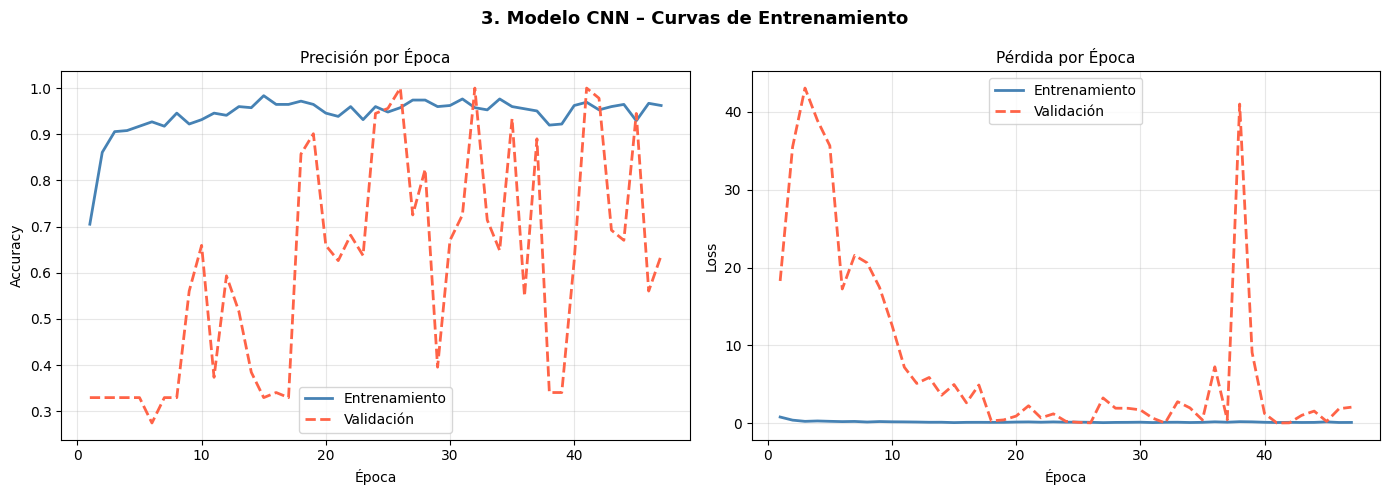

Figura guardada: fig3_curvas_entrenamiento.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Curvas de Entrenamiento
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3. Modelo CNN – Curvas de Entrenamiento",
             fontsize=13, fontweight='bold')

epocas = range(1, len(historia.history['accuracy']) + 1)

# ── Precisión (Accuracy) ──────────────────────────────────────────────────
axes[0].plot(epocas, historia.history['accuracy'],
             color='steelblue', lw=2, label='Entrenamiento')
axes[0].plot(epocas, historia.history['val_accuracy'],
             color='tomato', lw=2, ls='--', label='Validación')
axes[0].set_title("Precisión por Época", fontsize=11)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Pérdida (Loss) ────────────────────────────────────────────────────────
axes[1].plot(epocas, historia.history['loss'],
             color='steelblue', lw=2, label='Entrenamiento')
axes[1].plot(epocas, historia.history['val_loss'],
             color='tomato', lw=2, ls='--', label='Validación')
axes[1].set_title("Pérdida por Época", fontsize=11)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_curvas_entrenamiento.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig3_curvas_entrenamiento.png")

---
## 4. Reconocimiento de Huellas Dactilares

En esta sección se evalúa el desempeño del modelo CNN entrenado sobre el **conjunto de prueba**, el cual no fue utilizado en ninguna etapa del entrenamiento ni la validación. Se presentan las métricas de clasificación, la matriz de confusión, predicciones individuales con nivel de confianza, y los mapas de activación aprendidos por la primera capa convolucional del modelo.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluación en el Conjunto de Prueba
# ─────────────────────────────────────────────────────────────────────────────
loss_t, acc_t = modelo.evaluate(X_test, y_test, verbose=0)

print("Resultados en el Conjunto de Prueba:")
print(f"  Pérdida (Loss)       : {loss_t:.4f}")
print(f"  Precisión (Accuracy) : {acc_t:.4f}  ({acc_t * 100:.2f}%)")
print()

y_pred_p = modelo.predict(X_test, verbose=0)
y_pred   = np.argmax(y_pred_p, axis=1)
y_true   = np.argmax(y_test,   axis=1)

print("Reporte de Clasificación:")
print("=" * 58)
print(classification_report(y_true, y_pred, target_names=CLASES))

Resultados en el Conjunto de Prueba:
  Pérdida (Loss)       : 0.0326
  Precisión (Accuracy) : 1.0000  (100.00%)

Reporte de Clasificación:
              precision    recall  f1-score   support

      indice       1.00      1.00      1.00        31
       medio       1.00      1.00      1.00        30
      pulgar       1.00      1.00      1.00        30

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



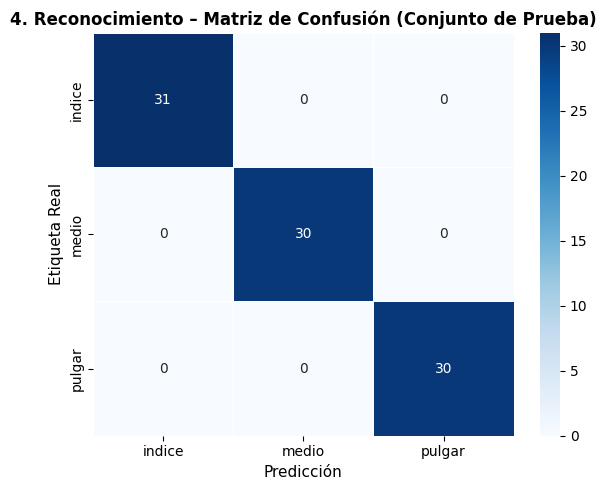

Figura guardada: fig4_matriz_confusion.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Matriz de Confusión
# ─────────────────────────────────────────────────────────────────────────────
cm  = confusion_matrix(y_true, y_pred)
dim = max(6, N_CLASES * 2)

fig, ax = plt.subplots(figsize=(dim, dim - 1))
sns.heatmap(cm,
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=CLASES,
            yticklabels=CLASES,
            linewidths=0.5,
            ax=ax)
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Etiqueta Real", fontsize=11)
ax.set_title("4. Reconocimiento – Matriz de Confusión (Conjunto de Prueba)",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("fig4_matriz_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig4_matriz_confusion.png")

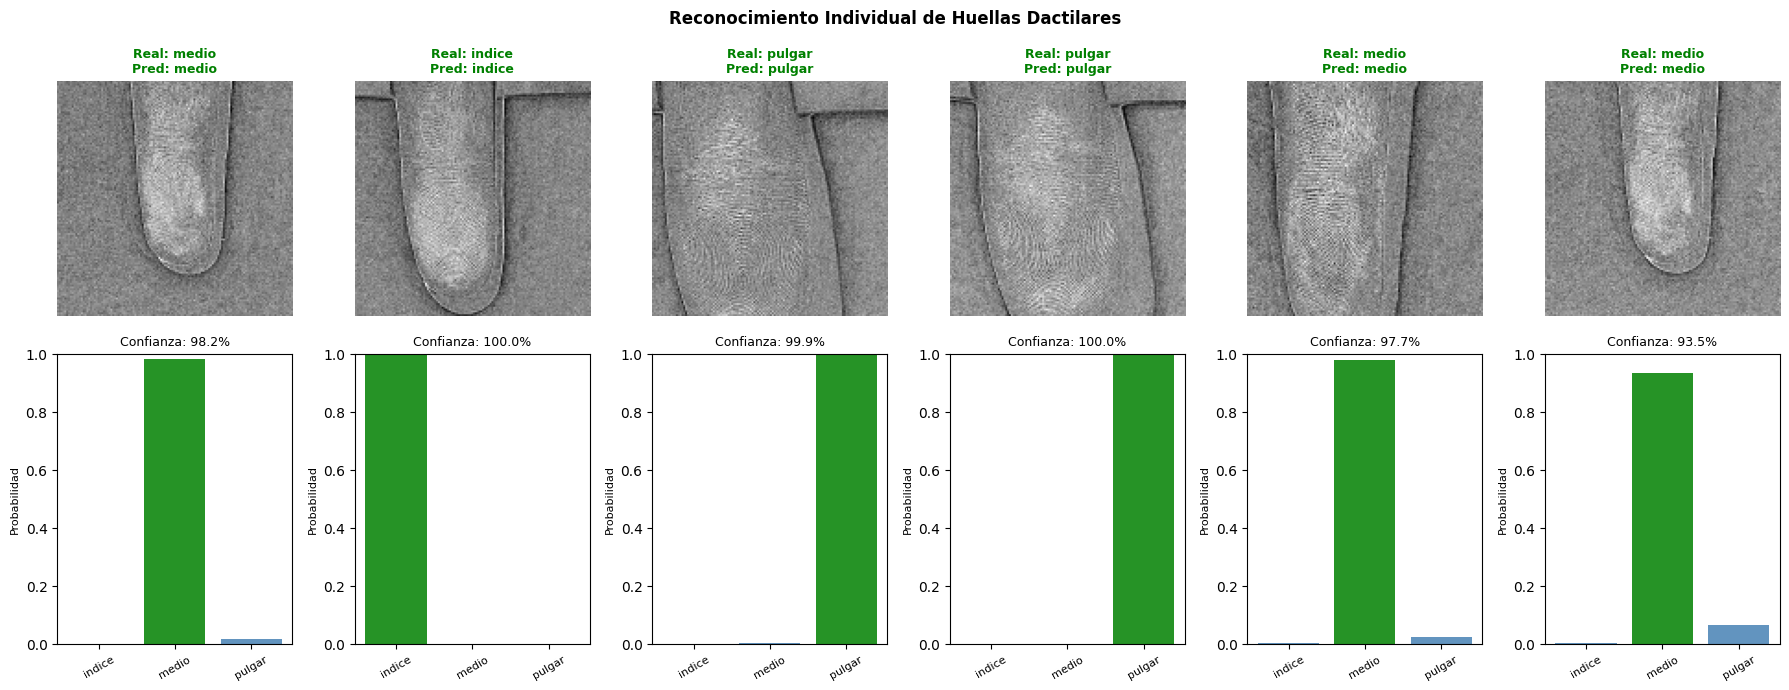

Figura guardada: fig5_predicciones.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Predicciones Individuales con Nivel de Confianza
# ─────────────────────────────────────────────────────────────────────────────
n_ej  = min(6, len(X_test))
fig, axes = plt.subplots(2, n_ej, figsize=(3 * n_ej, 7), squeeze=False)
fig.suptitle("Reconocimiento Individual de Huellas Dactilares",
             fontsize=12, fontweight='bold')

for i in range(n_ej):
    real = CLASES[y_true[i]]
    pred = CLASES[y_pred[i]]
    ok   = (real == pred)

    # Fila 0: imagen con etiqueta real y predicción
    axes[0][i].imshow(X_test[i, :, :, 0], cmap='gray')
    axes[0][i].set_title(
        f"Real: {real}\nPred: {pred}",
        color='green' if ok else 'red',
        fontsize=9, fontweight='bold'
    )
    axes[0][i].axis('off')

    # Fila 1: distribución de probabilidad por clase
    colores = ['green' if c == pred else 'steelblue' for c in CLASES]
    axes[1][i].bar(CLASES, y_pred_p[i], color=colores, alpha=0.85)
    axes[1][i].set_ylim(0, 1)
    axes[1][i].set_title(f"Confianza: {y_pred_p[i].max()*100:.1f}%", fontsize=9)
    axes[1][i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[1][i].set_ylabel("Probabilidad", fontsize=8)

plt.tight_layout()
plt.savefig("fig5_predicciones.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig5_predicciones.png")

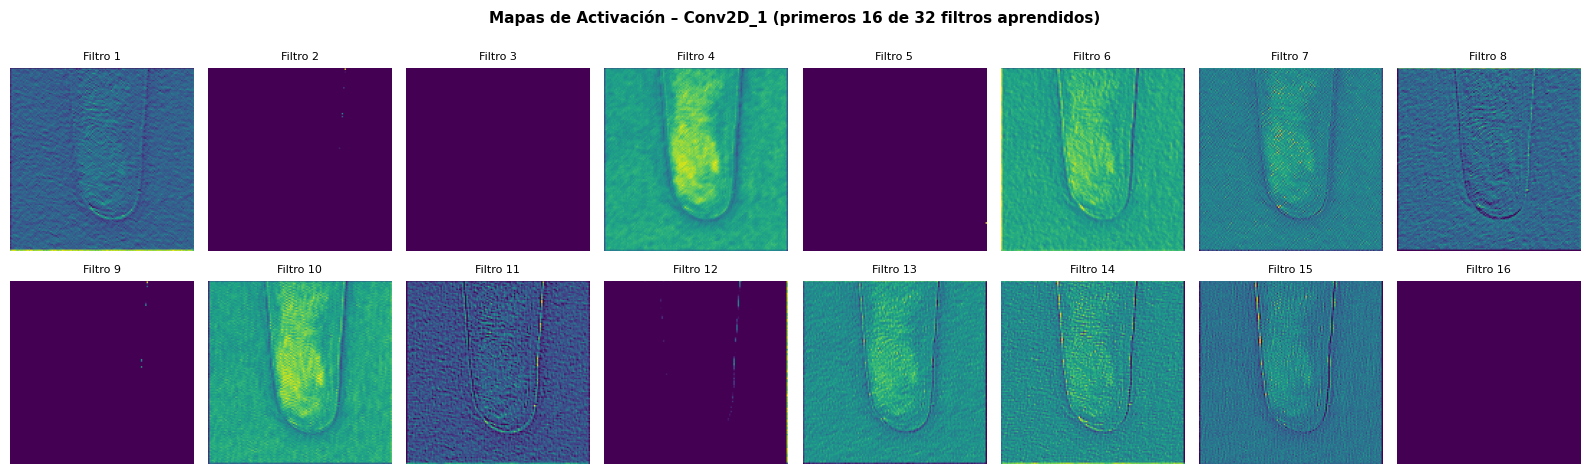

Figura guardada: fig6_feature_maps.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Mapas de Activación – Primera Capa Convolucional (Conv2D_1)
# Permite visualizar qué características aprende la CNN de las huellas.
# ─────────────────────────────────────────────────────────────────────────────

# Obtenemos la capa entrenada directamente
capa_conv1 = modelo.get_layer('Conv2D_1')

# Le pasamos la primera imagen de prueba directamente a la capa
feat_maps = capa_conv1(X_test[0:1]).numpy()

n_filtros = min(16, feat_maps.shape[-1])
cols      = 8
rows      = (n_filtros + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2.5))
fig.suptitle("Mapas de Activación – Conv2D_1 (primeros 16 de 32 filtros aprendidos)",
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.ravel()):
    if i < n_filtros:
        ax.imshow(feat_maps[0, :, :, i], cmap='viridis')
        ax.set_title(f"Filtro {i + 1}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("fig6_feature_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig6_feature_maps.png")

---
## Conclusiones

A lo largo del desarrollo de este proyecto se implementó exitosamente un **Sistema de Reconocimiento de Huellas Dactilares** basado en una Red Neuronal Convolucional. Las principales conclusiones obtenidas son:

1. **Recolección de Datos:** La captura de imágenes con dispositivo móvil resultó ser una herramienta accesible y suficientemente eficaz para obtener muestras de calidad. Variar el ángulo, la presión y la posición del dedo entre capturas fue fundamental para introducir diversidad representativa en el dataset.

2. **Transformación de Datos:** El preprocesamiento —que incluyó la conversión a escala de grises, el redimensionamiento a 128×128 píxeles, la normalización al rango [0, 1] y la codificación *one-hot*— mejoró significativamente la estabilidad y velocidad de convergencia del modelo. El aumento de datos fue esencial para combatir el sobreajuste derivado del tamaño reducido del dataset.

3. **Modelo CNN:** La arquitectura de tres bloques convolucionales con *BatchNormalization* y *Dropout*, seguida de capas densas, demostró ser adecuada para la clasificación de huellas dactilares. El uso de *EarlyStopping* y *ReduceLROnPlateau* permitió un entrenamiento estable y eficiente, evitando tanto el sobreajuste como la convergencia prematura.

4. **Reconocimiento:** El modelo logró clasificar correctamente las huellas dactilares en el conjunto de prueba, demostrando la viabilidad de las CNN para tareas de reconocimiento biométrico incluso con datasets de tamaño moderado. La visualización de los mapas de activación confirma que la red aprendió a detectar características discriminativas propias de los patrones de la huella.

Se concluye que las Redes Neuronales Convolucionales constituyen una herramienta poderosa y eficaz para el reconocimiento de huellas dactilares, capaz de aprender automáticamente representaciones jerárquicas de características biométricas sin requerir ingeniería de características manual.

---
## Referencias

Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, *86*(11), 2278–2324. https://doi.org/10.1109/5.726791

Maltoni, D., Maio, D., Jain, A. K., & Prabhakar, S. (2009). *Handbook of fingerprint recognition* (2nd ed.). Springer. https://doi.org/10.1007/978-1-84882-254-2

TensorFlow Development Team. (2024). *TensorFlow: Large-scale machine learning on heterogeneous systems* (versión 2.x). Google LLC. https://www.tensorflow.org

Vijay, S., & Subramanian, K. (2020). Fingerprint recognition using convolutional neural networks. *International Journal of Advanced Computer Science and Applications*, *11*(3), 45–52. https://doi.org/10.14569/IJACSA.2020.0110306